# Step 3 — Model Training

This notebook trains and compares three deep learning architectures for predicting future protein coordinates:

1. **CNN (1D Convolutional)**: Captures local temporal patterns through convolutional filters
2. **LSTM (Long Short-Term Memory)**: Models long-range temporal dependencies with recurrent connections
3. **Transformer**: Uses self-attention to weigh the importance of different timesteps

## Task Definition

- **Input**: W timesteps of 96 features (32 latent coords + 32 latent forces + 32 latent velocity)
- **Output**: 32 latent coordinates at timestep t+10 (shift=10)
- **Window sizes**: W = 10, 30, 60 (to compare short vs long context)

## Evaluation

All models are evaluated using:
- **MSE (Mean Squared Error)**: Primary metric for regression
- **MAE (Mean Absolute Error)**: Secondary metric, more interpretable

The data was preprocessed and split in Step 1:
- Train: 70% (35,000 samples)
- Validation: 20% (10,000 samples)  
- Test: 10% (5,001 samples)

In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# =============================================================
# REPRODUCIBILITY - Set all random seeds
# =============================================================
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("ENVIRONMENT SETUP")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Random seed: {SEED}")

# Check GPU availability
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU available: {gpus[0].name}")
    # Limit GPU memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU: Not available (using CPU)")

print("=" * 60)

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


ENVIRONMENT SETUP
TensorFlow version: 2.20.0
Random seed: 42
GPU: Not available (using CPU)


## Load Preprocessed Data

We load the train/validation/test datasets created in Step 1 (preprocessing notebook).

Each dataset contains 96 features per timestep:
- **Coord_0 to Coord_31**: Latent coordinates (from autoencoder)
- **Force_0 to Force_31**: Latent forces (from autoencoder)
- **Vel_0 to Vel_31**: Latent velocity (from autoencoder)

In [4]:
print("=" * 60)
print("LOADING PREPROCESSED DATA")
print("=" * 60)

# Path to preprocessed data (adjust if needed)
DATA_PATH = "../Step_1_Preprocessing/processed_step2"

# Load datasets
train_df = pd.read_csv(os.path.join(DATA_PATH, "train_dataset.csv"))
val_df = pd.read_csv(os.path.join(DATA_PATH, "val_dataset.csv"))
test_df = pd.read_csv(os.path.join(DATA_PATH, "test_dataset.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

print(f"\nFeatures: {train_df.columns[:3].tolist()} ... {train_df.columns[-3:].tolist()}")
print(f"Total features: {len(train_df.columns)}")

# Verify no NaN values
assert train_df.isna().sum().sum() == 0, "NaN in train!"
assert val_df.isna().sum().sum() == 0, "NaN in val!"
assert test_df.isna().sum().sum() == 0, "NaN in test!"
print("\nNo missing values in any dataset")

LOADING PREPROCESSED DATA
Train shape: (35000, 96)
Val shape:   (10000, 96)
Test shape:  (5001, 96)

Features: ['Coord_0', 'Coord_1', 'Coord_2'] ... ['Vel_29', 'Vel_30', 'Vel_31']
Total features: 96

No missing values in any dataset


## WindowGenerator Class

The WindowGenerator creates sliding windows for supervised time-series learning:

- **Input**: W consecutive timesteps (all 96 features)
- **Target**: Coordinates at timestep t+S (only 32 coordinate features)

### Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| Input Width (W) | 10, 30, 60 | Number of past timesteps |
| Label Width | 1 | Predict single future timestep |
| Shift (S) | 10 | How far ahead to predict |

### Shuffling Strategy

- **Train**: Shuffled for better gradient descent
- **Val/Test**: Not shuffled to preserve temporal order

In [5]:
print("=" * 60)
print("WINDOW GENERATOR SETUP")
print("=" * 60)

class WindowGenerator:
    """
    Creates sliding windows for time-series supervised learning.
    """
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 label_columns=None, batch_size=32):
        
        # Store data
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size
        
        # Label columns (what we want to predict)
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}
        
        # Window parameters
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        
        self.total_window_size = input_width + shift
        
        # Slices for splitting windows
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]
        
        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]
    
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        
        return inputs, labels
    
    def make_dataset(self, data, shuffle):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=self.batch_size,
        )
        ds = ds.map(self.split_window)
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)
        return ds
    
    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)
    
    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)
    
    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)
    
    def __repr__(self):
        return "\n".join([
            f"Window: input={self.input_width}, shift={self.shift}, total={self.total_window_size}",
            f"Target: {len(self.label_columns)} features"
        ])

# Define target columns (only coordinates)
LATENT_DIM = 32
label_columns = [f"Coord_{i}" for i in range(LATENT_DIM)]

# Hyperparameters
SHIFT = 10
BATCH_SIZE = 32

# Create windows with different input widths
w10 = WindowGenerator(
    input_width=10, label_width=1, shift=SHIFT,
    train_df=train_df, val_df=val_df, test_df=test_df,
    label_columns=label_columns, batch_size=BATCH_SIZE
)

w30 = WindowGenerator(
    input_width=30, label_width=1, shift=SHIFT,
    train_df=train_df, val_df=val_df, test_df=test_df,
    label_columns=label_columns, batch_size=BATCH_SIZE
)

w60 = WindowGenerator(
    input_width=60, label_width=1, shift=SHIFT,
    train_df=train_df, val_df=val_df, test_df=test_df,
    label_columns=label_columns, batch_size=BATCH_SIZE
)

print("Window configurations created:")
print(f"\n[W=10] {w10}")
print(f"\n[W=30] {w30}")
print(f"\n[W=60] {w60}")

# Verify shapes
print("\n" + "=" * 60)
print("VERIFYING WINDOW SHAPES")
print("=" * 60)

for name, window in [("W=10", w10), ("W=30", w30), ("W=60", w60)]:
    for batch in window.train.take(1):
        inputs, labels = batch
        print(f"{name}: Input={inputs.shape}, Labels={labels.shape}")

WINDOW GENERATOR SETUP
Window configurations created:

[W=10] Window: input=10, shift=10, total=20
Target: 32 features

[W=30] Window: input=30, shift=10, total=40
Target: 32 features

[W=60] Window: input=60, shift=10, total=70
Target: 32 features

VERIFYING WINDOW SHAPES
W=10: Input=(32, 10, 96), Labels=(32, 1, 32)
W=30: Input=(32, 30, 96), Labels=(32, 1, 32)
W=60: Input=(32, 60, 96), Labels=(32, 1, 32)


## Model 1 — CNN (1D Convolutional)

### Architecture Overview

A 1D Convolutional Neural Network processes temporal sequences by applying convolutional filters along the time axis. This allows the model to learn local temporal patterns.

### Architecture Design

### Hyperparameter Configurations

| Config | Filters | Kernel Size | Dense Units | Dropout |
|--------|---------|-------------|-------------|---------|
| Small  | 32, 64, 64 | 3 | 64 | 0.1 |
| Medium | 64, 128, 128 | 3 | 128 | 0.2 |
| Large  | 128, 256, 256 | 3 | 256 | 0.2 |

### Experiments

- 3 configurations × 3 window sizes = **9 experiments**
- Early stopping with patience=10
- Best model saved based on validation loss

In [6]:
print("=" * 60)
print("MODEL 1: CNN (1D CONVOLUTIONAL)")
print("=" * 60)

# =============================================================
# CNN CONFIGURATIONS
# =============================================================

CNN_CONFIGS = {
    "small": {
        "filters": [32, 64],
        "kernel_size": 3,
        "dense_units": 64,
        "dropout": 0.1,
        "learning_rate": 1e-3,
    },
    "medium": {
        "filters": [64, 128],
        "kernel_size": 3,
        "dense_units": 128,
        "dropout": 0.2,
        "learning_rate": 1e-3,
    },
    "large": {
        "filters": [128, 256],
        "kernel_size": 3,
        "dense_units": 256,
        "dropout": 0.2,
        "learning_rate": 1e-4,
    },
}

WINDOWS = {"W10": w10, "W30": w30, "W60": w60}

# Training settings
EPOCHS = 50
PATIENCE = 10
N_FEATURES = 96
N_OUTPUTS = 32

# =============================================================
# CNN MODEL BUILDER (PARAMETRIC + CAUSAL)
# =============================================================

def build_cnn(input_shape, config, n_outputs=N_OUTPUTS):
    """
    Build a parametric 1D CNN model with CAUSAL padding.
    
    Causal padding ensures the model only sees past timesteps,
    which is essential for time-series forecasting.
    
    Args:
        input_shape: tuple (timesteps, features)
        config: dict with filters, kernel_size, dense_units, dropout, learning_rate
        n_outputs: number of output features
    
    Returns:
        Compiled Keras model
    """
    model = tf.keras.Sequential(name="CNN_1D_Causal")
    
    # Input layer
    model.add(layers.Input(shape=input_shape))
    
    # Convolutional blocks with CAUSAL padding
    for i, n_filters in enumerate(config["filters"]):
        model.add(layers.Conv1D(
            filters=n_filters,
            kernel_size=config["kernel_size"],
            padding="causal",  # CRITICAL: ensures temporal causality
            activation="relu",
            name=f"conv_{i+1}"
        ))
        model.add(layers.Dropout(config["dropout"], name=f"dropout_{i+1}"))
    
    # Global pooling
    model.add(layers.GlobalAveragePooling1D(name="global_pool"))
    
    # Dense layers
    model.add(layers.Dense(config["dense_units"], activation="relu", name="dense"))
    
    # Output layer
    model.add(layers.Dense(n_outputs, name="output"))
    
    # Reshape to match label shape (batch, 1, 32)
    model.add(layers.Reshape((1, n_outputs), name="reshape"))
    
    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="mse",
        metrics=["mae"]
    )
    
    return model

# =============================================================
# TRAINING FUNCTION
# =============================================================

def train_and_evaluate(model, window, model_name, epochs=EPOCHS, patience=PATIENCE):
    """
    Train model with early stopping and evaluate on test set.
    """
    import time
    
    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )
    
    # Train
    start_time = time.time()
    history = model.fit(
        window.train,
        validation_data=window.val,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    train_time = time.time() - start_time
    
    # Evaluate on test set
    test_metrics = model.evaluate(window.test, verbose=0)
    
    return history, test_metrics, train_time

# =============================================================
# RESULTS STORAGE
# =============================================================

cnn_results = []

# =============================================================
# RUN CNN EXPERIMENTS
# =============================================================

print(f"\nRunning {len(CNN_CONFIGS)} configs × {len(WINDOWS)} windows = {len(CNN_CONFIGS) * len(WINDOWS)} experiments\n")

for config_name, config in CNN_CONFIGS.items():
    for window_name, window in WINDOWS.items():
        
        # Get input shape from window
        input_width = window.input_width
        input_shape = (input_width, N_FEATURES)
        
        # Build model
        model = build_cnn(input_shape, config)
        
        # Model name for logging
        exp_name = f"CNN_{config_name}_{window_name}"
        print(f"Training {exp_name}...", end=" ")
        
        # Train and evaluate
        history, test_metrics, train_time = train_and_evaluate(model, window, exp_name)
        
        # Store results
        result = {
            "model": "CNN",
            "config": config_name,
            "window": window_name,
            "input_width": input_width,
            "params": model.count_params(),
            "epochs_trained": len(history.history["loss"]),
            "train_time": round(train_time, 1),
            "train_mse": round(history.history["loss"][-1], 6),
            "train_mae": round(history.history["mae"][-1], 6),
            "val_mse": round(history.history["val_loss"][-1], 6),
            "val_mae": round(history.history["val_mae"][-1], 6),
            "test_mse": round(test_metrics[0], 6),
            "test_mae": round(test_metrics[1], 6),
        }
        cnn_results.append(result)
        
        print(f"Done! Test MSE: {result['test_mse']:.6f}, Time: {result['train_time']}s")
        
        # Clear memory
        del model
        tf.keras.backend.clear_session()

# =============================================================
# DISPLAY CNN RESULTS
# =============================================================

print("\n" + "=" * 60)
print("CNN RESULTS SUMMARY")
print("=" * 60)

cnn_results_df = pd.DataFrame(cnn_results)
print(cnn_results_df.to_string(index=False))

# Save results
os.makedirs("results", exist_ok=True)
cnn_results_df.to_csv("results/cnn_results.csv", index=False)
print("\nResults saved to results/cnn_results.csv")

MODEL 1: CNN (1D CONVOLUTIONAL)

Running 3 configs × 3 windows = 9 experiments

Training CNN_small_W10... Done! Test MSE: 0.072733, Time: 50.4s
Training CNN_small_W30... Done! Test MSE: 0.059309, Time: 54.3s
Training CNN_small_W60... Done! Test MSE: 0.077170, Time: 78.2s
Training CNN_medium_W10... Done! Test MSE: 0.191573, Time: 56.5s
Training CNN_medium_W30... Done! Test MSE: 0.095689, Time: 89.3s
Training CNN_medium_W60... Done! Test MSE: 0.082866, Time: 95.4s
Training CNN_large_W10... Done! Test MSE: 0.055958, Time: 105.5s
Training CNN_large_W30... Done! Test MSE: 0.085573, Time: 142.0s
Training CNN_large_W60... Done! Test MSE: 0.115909, Time: 215.8s

CNN RESULTS SUMMARY
model config window  input_width  params  epochs_trained  train_time  train_mse  train_mae  val_mse  val_mae  test_mse  test_mae
  CNN  small    W10           10   21696              13        50.4   0.001842   0.023488 0.092068 0.214162  0.072733  0.216734
  CNN  small    W30           30   21696              12   

<span style="color:red">Capire rispetto al vecchio l'architettura</span><br>
<span style="color:red">Capire cosa va controllato nel confronto</span><br>
<span style="color:red">Capire dove prendo il true value</span><br>


## Model 2 — LSTM (Long Short-Term Memory)

### Architecture Overview

LSTM networks are designed to learn long-range temporal dependencies through gating mechanisms that control information flow. They are well-suited for sequential data where past context influences future predictions.

### Architecture Design
```
Input (W, 96) → LSTM → Dropout → LSTM → Dropout → Dense → Output (1, 32)
```

For smaller configs, we use a single LSTM layer. For larger configs, we stack two LSTM layers.

### Hyperparameter Configurations

| Config | LSTM Units | Layers | Dropout | Learning Rate |
|--------|------------|--------|---------|---------------|
| Small  | 64         | 1      | 0.1     | 1e-3          |
| Medium | 128        | 2      | 0.2     | 1e-3          |
| Large  | 256        | 2      | 0.2     | 1e-4          |

### Experiments

- 3 configurations × 3 window sizes = **9 experiments**
- Early stopping with patience=10
- Best model saved based on validation loss

In [7]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, callbacks

print("=" * 60)
print("MODEL 2: LSTM (RECURRENT)")
print("=" * 60)

LSTM_CONFIGS = {
    "small": {
        "units": [64],
        "dropout": 0.1,
        "recurrent_dropout": 0.0,
        "learning_rate": 1e-3,
    },
    "medium": {
        "units": [128, 64],
        "dropout": 0.2,
        "recurrent_dropout": 0.0,
        "learning_rate": 1e-3,
    },
    "large": {
        "units": [256, 128],
        "dropout": 0.2,
        "recurrent_dropout": 0.0,
        "learning_rate": 1e-4,
    },
}

WINDOWS = {"W10": w10, "W30": w30, "W60": w60}

EPOCHS = 50
PATIENCE = 10
N_OUTPUTS = 32


def infer_n_features(window) -> int:
    xb, _ = next(iter(window.train.take(1)))
    return int(xb.shape[-1])


def build_lstm(input_shape, config, n_outputs=N_OUTPUTS):
    model = tf.keras.Sequential(name="LSTM")

    model.add(layers.Input(shape=input_shape))

    n_layers = len(config["units"])
    for i, units in enumerate(config["units"]):
        return_seq = (i < n_layers - 1)
        model.add(
            layers.LSTM(
                units=units,
                return_sequences=return_seq,
                dropout=config["dropout"],
                recurrent_dropout=config["recurrent_dropout"],
                name=f"lstm_{i+1}",
            )
        )

    model.add(layers.Dense(n_outputs, name="output"))
    model.add(layers.Reshape((1, n_outputs), name="reshape"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="mse",
        metrics=["mae"],
    )
    return model


def train_and_evaluate(model, window, epochs=EPOCHS, patience=PATIENCE):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=0,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0,
    )

    start = time.time()
    history = model.fit(
        window.train,
        validation_data=window.val,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )
    train_time = time.time() - start

    test_metrics = model.evaluate(window.test, verbose=0)

    hist = history.history
    best_epoch = int(np.argmin(hist["val_loss"]) + 1)
    best_val_mse = float(np.min(hist["val_loss"]))
    best_val_mae = float(np.min(hist["val_mae"]))
    best_train_mse = float(hist["loss"][best_epoch - 1])
    best_train_mae = float(hist["mae"][best_epoch - 1])

    return history, test_metrics, train_time, best_epoch, best_train_mse, best_train_mae, best_val_mse, best_val_mae


print(f"\nRunning {len(LSTM_CONFIGS)} configs × {len(WINDOWS)} windows = {len(LSTM_CONFIGS) * len(WINDOWS)} experiments\n")

lstm_results = []

for window_name, window in WINDOWS.items():
    n_features = infer_n_features(window)
    input_width = int(window.input_width)
    print(f"{window_name}: input_width={input_width}, n_features={n_features}")

for config_name, config in LSTM_CONFIGS.items():
    for window_name, window in WINDOWS.items():
        input_width = int(window.input_width)
        n_features = infer_n_features(window)
        input_shape = (input_width, n_features)

        model = build_lstm(input_shape, config)

        exp_name = f"LSTM_{config_name}_{window_name}"
        print(f"Training {exp_name}...", end=" ")

        history, test_metrics, train_time, best_epoch, best_train_mse, best_train_mae, best_val_mse, best_val_mae = train_and_evaluate(
            model, window
        )

        result = {
            "model": "LSTM",
            "config": config_name,
            "window": window_name,
            "input_width": input_width,
            "n_features": n_features,
            "params": int(model.count_params()),
            "epochs_trained": int(len(history.history["loss"])),
            "best_epoch": best_epoch,
            "train_time_s": round(train_time, 1),
            "best_train_mse": round(best_train_mse, 6),
            "best_train_mae": round(best_train_mae, 6),
            "best_val_mse": round(best_val_mse, 6),
            "best_val_mae": round(best_val_mae, 6),
            "test_mse": round(float(test_metrics[0]), 6),
            "test_mae": round(float(test_metrics[1]), 6),
        }
        lstm_results.append(result)

        print(f"Done! Test MSE: {result['test_mse']:.6f}, Time: {result['train_time_s']}s, Best epoch: {best_epoch}")

        del model
        tf.keras.backend.clear_session()


print("\n" + "=" * 60)
print("LSTM RESULTS SUMMARY")
print("=" * 60)

lstm_results_df = pd.DataFrame(lstm_results).sort_values(["test_mse", "best_val_mse"])
print(lstm_results_df.to_string(index=False))

os.makedirs("results", exist_ok=True)
lstm_results_df.to_csv("results/lstm_results.csv", index=False)
print("\nResults saved to results/lstm_results.csv")


MODEL 2: LSTM (RECURRENT)

Running 3 configs × 3 windows = 9 experiments

W10: input_width=10, n_features=96
W30: input_width=30, n_features=96
W60: input_width=60, n_features=96
Training LSTM_small_W10... 

KeyboardInterrupt: 

## Short-term dynamics analysis and forecasting difficulty

Before training forecasting models, we analyze the short-term temporal behavior of the latent
coordinates obtained after dimensionality reduction.

This analysis is motivated by the fact that in Molecular Dynamics (MD) simulations the temporal
evolution of atomic positions is typically continuous and smooth over short time scales.
If the system changes only marginally between consecutive timesteps, short-horizon forecasting
may become a trivial task, where simple persistence-based baselines already achieve near-optimal
performance.

To quantify this effect, we perform three complementary analyses on the latent coordinate space.

### MSE between latent states at different time lags

We compute the mean squared error (MSE) between latent coordinate vectors at time $t$ and
$t + \Delta$, for increasing values of the lag $\Delta$.

Figure X shows the MSE as a function of the temporal lag on a logarithmic scale.
For small lags (up to $\Delta = 10$), the MSE remains extremely low ($\sim 10^{-6}$),
indicating that the latent coordinates change only minimally in the short term.
As the lag increases, the error grows approximately monotonically, confirming the presence
of slow but non-negligible long-term dynamics.

This result suggests that short-horizon prediction tasks may be dominated by trivial
persistence effects.

### Step-to-step variation magnitude

To further characterize the temporal smoothness, we compute the L2 norm of the difference
between consecutive latent states, $\|\mathbf{x}_{t} - \mathbf{x}_{t-1}\|$.

Figure Y shows that step-to-step variations remain small throughout most of the trajectory,
with gradual changes over time and only occasional peaks corresponding to larger structural
rearrangements.

This behavior is consistent with the physical continuity of molecular dynamics trajectories.

### Qualitative inspection of individual latent coordinates

Finally, we inspect the temporal evolution of individual latent coordinates.
Figure Z illustrates a representative latent dimension over a selected time interval.
The trajectory exhibits smooth, slowly varying behavior without abrupt discontinuities,
providing qualitative confirmation of the quantitative analyses above.

### Implications for forecasting models

The combination of these analyses indicates that short-term forecasting of latent coordinates
is nearly trivial for small prediction horizons.
In this regime, simple persistence baselines are expected to achieve very low error, limiting
the observable benefits of more complex models such as CNNs or recurrent architectures.

This observation motivates the evaluation of learning-based models at longer prediction horizons,
where non-trivial temporal dependencies become more pronounced and the advantages of sequence
models can be meaningfully assessed.


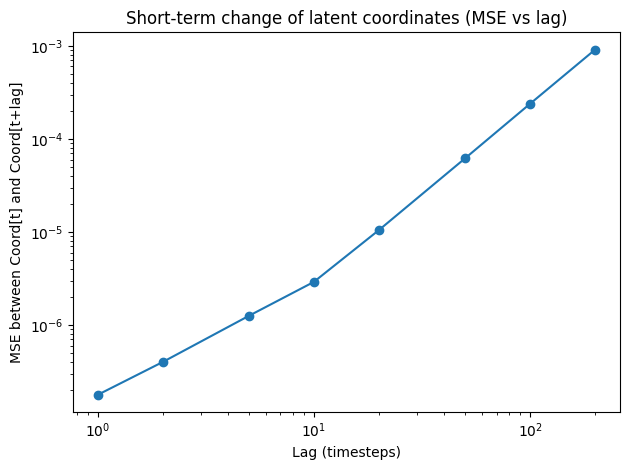

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("eval_figs", exist_ok=True)

LATENT_DIM = 32
coord_cols = [f"Coord_{i}" for i in range(LATENT_DIM)]

X = train_df[coord_cols].to_numpy(dtype=np.float32)

lags = [1, 2, 5, 10, 20, 50, 100, 200]
mse_lag = []

for lag in lags:
    a = X[:-lag]
    b = X[lag:]
    mse = np.mean((a - b) ** 2)
    mse_lag.append(mse)

plt.figure()
plt.plot(lags, mse_lag, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lag (timesteps)")
plt.ylabel("MSE between Coord[t] and Coord[t+lag]")
plt.title("Short-term change of latent coordinates (MSE vs lag)")
plt.tight_layout()
plt.savefig("eval_figs/mse_vs_lag.jpeg", dpi=300)
plt.show()


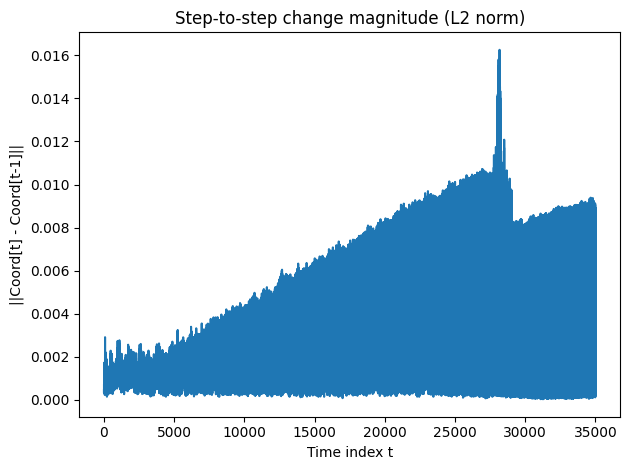

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("eval_figs", exist_ok=True)

LATENT_DIM = 32
coord_cols = [f"Coord_{i}" for i in range(LATENT_DIM)]
X = train_df[coord_cols].to_numpy(dtype=np.float32)

d1 = X[1:] - X[:-1]
step_norm = np.linalg.norm(d1, axis=1)

plt.figure()
plt.plot(step_norm)
plt.xlabel("Time index t")
plt.ylabel("||Coord[t] - Coord[t-1]||")
plt.title("Step-to-step change magnitude (L2 norm)")
plt.tight_layout()
plt.savefig("eval_figs/step_change_norm.jpeg", dpi=300)
plt.show()


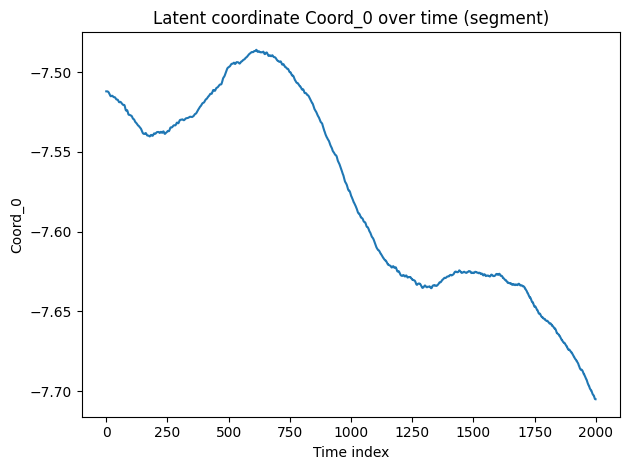

In [18]:
import matplotlib.pyplot as plt
import os

os.makedirs("eval_figs", exist_ok=True)

k = 0
series = train_df[f"Coord_{k}"].to_numpy()

start = 0
length = 2000  # cambia se vuoi

plt.figure()
plt.plot(series[start:start+length])
plt.xlabel("Time index")
plt.ylabel(f"Coord_{k}")
plt.title(f"Latent coordinate Coord_{k} over time (segment)")
plt.tight_layout()
plt.savefig(f"eval_figs/coord_{k}_segment.jpeg", dpi=300)
plt.show()


In [12]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, callbacks, models

print("=" * 60)
print("MODEL 3: TRANSFORMER (SELF-ATTENTION) - TUNED")
print("=" * 60)

# =============================================================
# CONFIGURAZIONI (Con d_model aggiunto)
# =============================================================
TRANSFORMER_CONFIGS = {
    "light": {
        "d_model": 64,
        "num_heads": 2,          # Pochissime teste
        "ff_dim": 64,            # Rete piccola
        "num_transformer_blocks": 1, # Solo 1 blocco!
        "mlp_units": [64],
        "dropout": 0.0,          # ZERO Dropout (facciamolo imparare tutto subito)
        "learning_rate": 1e-3,   # Torniamo a 1e-3 (più aggressivo)
    },
    # Teniamo una versione media giusto per confronto
    "medium_fast": {
        "d_model": 128,
        "num_heads": 4,
        "ff_dim": 128,
        "num_transformer_blocks": 2,
        "mlp_units": [128],
        "dropout": 0.1,          # Poco dropout
        "learning_rate": 1e-3,
    },
}

# Assicurati che w10, w30, w60 siano definiti nel notebook
WINDOWS = {"W10": w10, "W30": w30, "W60": w60}

EPOCHS = 100    # Aumentato per dare tempo al LR basso
PATIENCE = 10   # Aumentato per evitare stop prematuri
N_OUTPUTS = 32

# =============================================================
# FUNZIONI UTILI
# =============================================================

def infer_n_features(window) -> int:
    # Estrae il numero di feature (96) dal primo batch
    xb, _ = next(iter(window.train.take(1)))
    return int(xb.shape[-1])

def add_positional_embedding(x, seq_len, d_model):
    # Genera indici 0, 1, ... seq_len-1
    positions = tf.range(start=0, limit=seq_len, delta=1)
    # Embedding: mappa gli indici a vettori di dimensione d_model
    pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)(positions)
    # Aggiunge dimensione batch (1, seq_len, d_model) per sommare correttamente
    return x + tf.expand_dims(pos_emb, axis=0)

def transformer_encoder_block(x, d_model, num_heads, ff_dim, dropout):
    # Calcolo dimensione per ogni testa
    if d_model % num_heads != 0:
        raise ValueError(f"d_model ({d_model}) deve essere divisibile per num_heads ({num_heads})")
    key_dim = d_model // num_heads

    # --- 1. Multi-Head Attention ---
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x_norm, x_norm)
    # Residual connection
    x = layers.Add()([x, attn])

    # --- 2. Feed Forward Network ---
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    # Parte "Dense" interna
    ff = layers.Dense(ff_dim, activation="relu")(x_norm)
    ff = layers.Dropout(dropout)(ff)
    # Proiezione finale
    ff = layers.Dense(d_model)(ff)
    ff = layers.Dropout(dropout)(ff)
    # Residual connection
    x = layers.Add()([x, ff])

    return x

def build_transformer(input_shape, config, n_outputs=N_OUTPUTS):
    seq_len, n_features = input_shape
    d_model = config["d_model"]

    inputs = layers.Input(shape=input_shape, name="inputs")

    # 1. Proiezione Input (96 -> d_model)
    x = layers.Dense(d_model, name="input_projection")(inputs)
    
    # 2. Positional Encoding
    x = add_positional_embedding(x, seq_len=seq_len, d_model=d_model)

    # 3. Transformer Blocks
    for i in range(config["num_transformer_blocks"]):
        x = transformer_encoder_block(
            x,
            d_model=d_model,
            num_heads=config["num_heads"],
            ff_dim=config["ff_dim"],
            dropout=config["dropout"],
        )

    # 4. Global Pooling (Media temporale)
    x = layers.GlobalAveragePooling1D(name="global_pool")(x)

    # 5. MLP Head finale
    for i, units in enumerate(config["mlp_units"]):
        x = layers.Dense(units, activation="relu", name=f"mlp_{i+1}")(x)
        x = layers.Dropout(config["dropout"], name=f"mlp_dropout_{i+1}")(x)

    # Output Layer
    outputs = layers.Dense(n_outputs, name="output")(x)
    outputs = layers.Reshape((1, n_outputs), name="reshape")(outputs)

    model = models.Model(inputs=inputs, outputs=outputs, name="Transformer")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="mse",
        metrics=["mae"],
    )
    return model

def train_and_evaluate(model, window, epochs=EPOCHS, patience=PATIENCE):
    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=0,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0,
    )

    start = time.time()
    history = model.fit(
        window.train,
        validation_data=window.val,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr],
        verbose=0, # Metto 0 per pulizia, metti 1 se vuoi vedere la barra
    )
    train_time = time.time() - start

    test_metrics = model.evaluate(window.test, verbose=0)

    # Recupero metriche migliori
    hist = history.history
    best_epoch = int(np.argmin(hist["val_loss"]) + 1)
    best_val_mse = float(np.min(hist["val_loss"]))
    best_val_mae = float(np.min(hist["val_mae"]))
    
    # Valori al 'best_epoch' (indice -1)
    best_train_mse = float(hist["loss"][best_epoch - 1])
    best_train_mae = float(hist["mae"][best_epoch - 1])

    return history, test_metrics, train_time, best_epoch, best_train_mse, best_train_mae, best_val_mse, best_val_mae


# =============================================================
# ESECUZIONE
# =============================================================

print(f"\nRunning {len(TRANSFORMER_CONFIGS)} configs × {len(WINDOWS)} windows = {len(TRANSFORMER_CONFIGS) * len(WINDOWS)} experiments\n")

transformer_results = []

for config_name, config in TRANSFORMER_CONFIGS.items():
    for window_name, window in WINDOWS.items():
        
        # Recupero dimensioni
        input_width = int(window.input_width)
        n_features = infer_n_features(window)
        input_shape = (input_width, n_features)

        # Build
        model = build_transformer(input_shape, config)
        
        exp_name = f"Transf_{config_name}_{window_name}"
        print(f"Training {exp_name}...", end=" ", flush=True)

        try:
            # Train
            history, test_metrics, train_time, best_epoch, best_train_mse, best_train_mae, best_val_mse, best_val_mae = train_and_evaluate(
                model, window
            )

            result = {
                "model": "Transformer",
                "config": config_name,
                "window": window_name,
                "input_width": input_width,
                "params": int(model.count_params()),
                "epochs_trained": int(len(history.history["loss"])),
                "best_epoch": best_epoch,
                "train_time_s": round(train_time, 1),
                "best_train_mse": round(best_train_mse, 6),
                "best_val_mse": round(best_val_mse, 6),
                "test_mse": round(float(test_metrics[0]), 6),
                "test_mae": round(float(test_metrics[1]), 6),
            }
            transformer_results.append(result)
            print(f"Done! Test MSE: {result['test_mse']:.6f}, Ep: {best_epoch}")

        except Exception as e:
            print(f"Error: {e}")
        
        # Cleanup
        del model
        tf.keras.backend.clear_session()

# =============================================================
# RISULTATI
# =============================================================

print("\n" + "=" * 60)
print("TRANSFORMER RESULTS SUMMARY")
print("=" * 60)

if transformer_results:
    transformer_results_df = pd.DataFrame(transformer_results).sort_values(["test_mse"])
    print(transformer_results_df.to_string(index=False))

    os.makedirs("results", exist_ok=True)
    transformer_results_df.to_csv("results/transformer_results.csv", index=False)
    print("\nResults saved to results/transformer_results.csv")
else:
    print("No results.")

MODEL 3: TRANSFORMER (SELF-ATTENTION) - TUNED

Running 2 configs × 3 windows = 6 experiments

Training Transf_light_W10... Done! Test MSE: 0.306414, Ep: 11
Training Transf_light_W30... Done! Test MSE: 0.142185, Ep: 21
Training Transf_light_W60... Done! Test MSE: 0.040454, Ep: 29
Training Transf_medium_fast_W10... Done! Test MSE: 0.206785, Ep: 4
Training Transf_medium_fast_W30... Done! Test MSE: 0.179944, Ep: 6
Training Transf_medium_fast_W60... Done! Test MSE: 0.242490, Ep: 5

TRANSFORMER RESULTS SUMMARY
      model      config window  input_width  params  epochs_trained  best_epoch  train_time_s  best_train_mse  best_val_mse  test_mse  test_mae
Transformer       light    W60           60   37664              39          29         516.9        0.000041      0.011753  0.040454  0.154405
Transformer       light    W30           30   37664              31          21         267.2        0.000054      0.027842  0.142185  0.304139
Transformer medium_fast    W30           30  232224       